# Forecasting Baselines: Short-Term Point Forecasts for Estimated WEC Power

This notebook builds simple short-term point-forecasting baselines for the estimated WEC power output prepared in the previous notebooks.

The input data used here is the 30-minute Leixões estimated WEC power time series. The sourcing and sea-state preparation are documented in [wave data preparation](01_wave_data_preparation.ipynb), and the simplified WEC power estimation procedure is documented in [WEC power estimation](02_wec_power_estimation.ipynb).

The main modelling target is `wec_power_norm_estimated`, which represents the estimated WEC power normalized by the nominal 250 kW rating used for the generic WEC proxy. This device-relative scale is useful for modelling because it keeps the target independent of larger rated-power or array-sizing assumptions.

For physical interpretation in plots and reported errors, the normalized target is also shown on the corresponding 250 kW scale:

`wec_power_kw_estimated = wec_power_norm_estimated × 250 kW`

The forecast target is not measured WEC power. It is also not a validated device model, hydrodynamic simulation, or wave-to-wire model. It is a simplified, transparent WEC power proxy derived from observed sea-state variables using the assumptions documented in the WEC power estimation notebook.

The purpose of this notebook is to create reproducible point-forecast baselines and residuals that can support the uncertainty and storage-aware subsequent analyses.

The benchmark uses a compact power-only autoregressive feature set. Wave-height, wave-period, and wave-power-flux variables are not used as predictors in the main benchmark, because the estimated WEC power target was itself constructed from sea-state assumptions. This avoids a forecast model that partly relearns the constructed power-matrix mapping instead of forecasting the estimated power series as a time-dependent signal.

The feature set is intentionally kept small: selected lag values, rolling means, and rolling standard deviations of the estimated power series. This keeps the benchmark interpretable and avoids turning the first forecasting notebook into a broad feature-search exercise.

The forecasting horizons are:

| Horizon | Steps | Operational context |
|---:|---:|---|
| 30 min | 1 | Grid-relevant: next balancing or dispatch interval |
| 1 h | 2 | Grid/storage-relevant: near-term operational planning |
| 2 h | 4 | Storage-relevant: short storage dispatch window |
| 4 h | 8 | Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs |

Missing target values are not imputed. Lag, rolling, and future target values are created only within continuous valid segments of the original 30-minute time axis. This prevents observations separated by data gaps from being treated as adjacent 30-minute observations.

Evaluation uses chronological rolling-origin folds. Each fold contains a training block, a calibration/validation block, and a final test block. Using several rolling-origin test folds gives multiple performance estimates across different time periods, which helps assess the stability of the forecasting baselines rather than relying on a single final split.

The notebook compares a small set of interpretable baseline models:

- Persistence
- Rolling mean
- Ridge regression
- Random forest regression

Performance is reported using MAE, RMSE, and skill scores relative to persistence.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths
data_path = Path("../data/processed/leixoes_wec_power_30min_estimated.parquet")

output_dir = Path("../outputs/notebook_03")
metrics_path = output_dir / "forecast_metrics.csv"
predictions_path = output_dir / "forecast_predictions.parquet"
folds_path = output_dir / "forecast_folds.csv"


# Target and physical interpretation scale
time_col = "time"
target_col = "wec_power_norm_estimated"
rated_power_kw = 250.0


# Forecast horizons for 30-minute data
horizons = {
    1: {
        "horizon_label": "30 min",
        "horizon_hours": 0.5,
        "operational_context": "Grid-relevant: next balancing or dispatch interval",
    },
    2: {
        "horizon_label": "1 h",
        "horizon_hours": 1.0,
        "operational_context": "Grid/storage-relevant: near-term operational planning",
    },
    4: {
        "horizon_label": "2 h",
        "horizon_hours": 2.0,
        "operational_context": "Storage-relevant: short storage dispatch window",
    },
    8: {
        "horizon_label": "4 h",
        "horizon_hours": 4.0,
        "operational_context": "Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs",
    },
}


# Power-only autoregressive features
lag_steps = [1, 2, 4, 8, 24]
roll_mean_windows = [3, 6, 12]
roll_std_windows = [6, 12]

feature_cols = (
    [f"power_lag_{step}" for step in lag_steps]
    + [f"power_roll_mean_{window}" for window in roll_mean_windows]
    + [f"power_roll_std_{window}" for window in roll_std_windows]
)


# Reproducibility
random_state = 42

## Target availability and continuous segments

Before creating forecasting features, the estimated power target is checked on the original 30-minute time axis.

Missing target values are kept as gaps. Continuous valid segments are identified so that lag, rolling, and future-target features can later be created only within uninterrupted parts of the series.

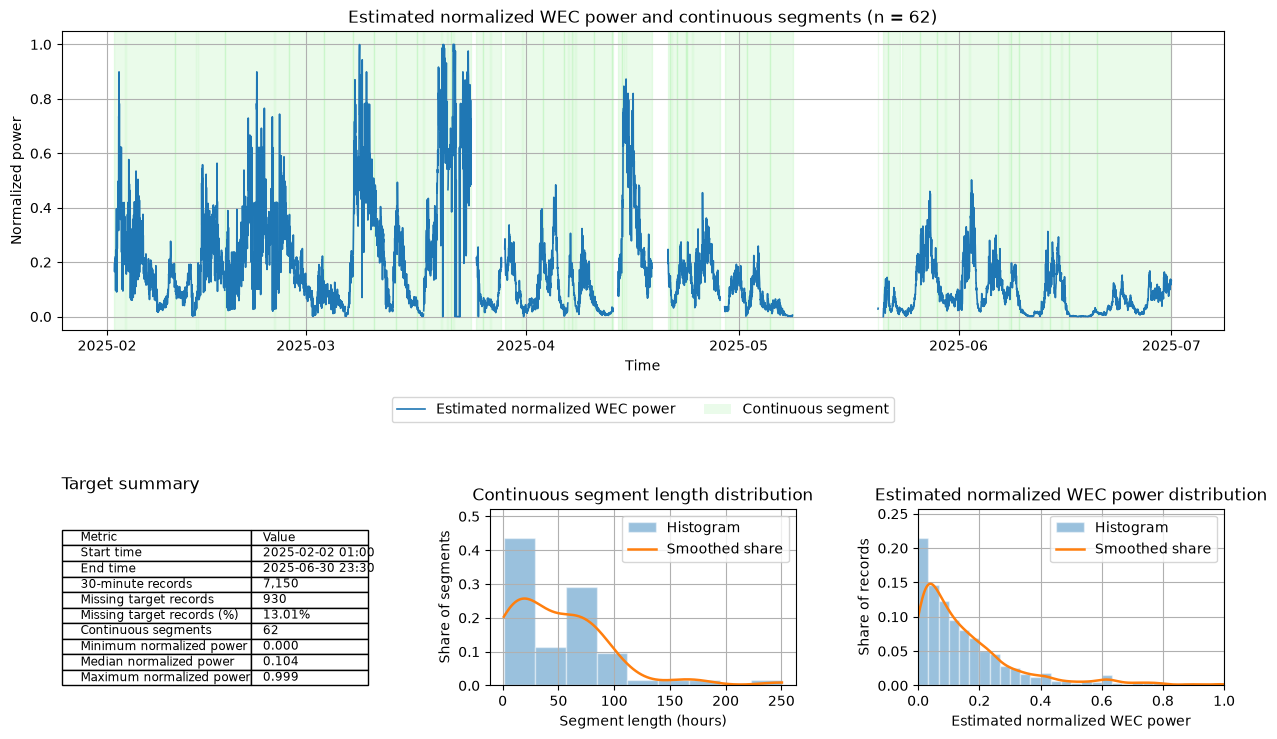

In [2]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(data_path).copy()

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

required_cols = [
    time_col,
    "hm0_m",
    "tp_s",
    "te_approx_s",
    "wave_power_flux_kw_m_estimated",
    "wec_power_kw_estimated",
    "wec_power_norm_estimated",
    "high_wave_flag",
    "matrix_input_missing_flag",
    "generic_wec_model_id",
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")


# Identify continuous non-missing target segments on the original 30-minute axis
df["target_available"] = df[target_col].notna()

time_step = pd.Timedelta(minutes=30)
time_gap = df[time_col].diff().ne(time_step)
availability_change = df["target_available"].ne(df["target_available"].shift())

df["continuous_segment_id"] = (time_gap | availability_change).cumsum()
df.loc[~df["target_available"], "continuous_segment_id"] = pd.NA

segment_summary = (
    df.loc[df["target_available"]]
    .groupby("continuous_segment_id", dropna=True)
    .agg(
        start_time=(time_col, "min"),
        end_time=(time_col, "max"),
        n_records=(target_col, "size"),
    )
    .reset_index()
)

segment_summary["duration_hours"] = segment_summary["n_records"] * 0.5


# Compact summary table
missing_count = df[target_col].isna().sum()
missing_pct = missing_count / len(df) * 100

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Start time",
            "End time",
            "30-minute records",
            "Missing target records",
            "Missing target records (%)",
            "Continuous segments",
            "Minimum normalized power",
            "Median normalized power",
            "Maximum normalized power",
        ],
        "Value": [
            df[time_col].min().strftime("%Y-%m-%d %H:%M"),
            df[time_col].max().strftime("%Y-%m-%d %H:%M"),
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{len(segment_summary):,}",
            f"{df[target_col].min():.3f}",
            f"{df[target_col].median():.3f}",
            f"{df[target_col].max():.3f}",
        ],
    }
)


# Target overview, segment lengths, and target distribution
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.3], hspace=0.75, wspace=0.4)

ax_ts = fig.add_subplot(gs[0, :])
ax_table = fig.add_subplot(gs[1, 0])
ax_hist_seg = fig.add_subplot(gs[1, 1])
ax_hist_power = fig.add_subplot(gs[1, 2])

for _, row in segment_summary.iterrows():
    ax_ts.axvspan(
        row["start_time"],
        row["end_time"],
        color="lightgreen",
        alpha=0.18,
        zorder=0,
    )

power_line, = ax_ts.plot(
    df[time_col],
    df[target_col],
    linewidth=1.2,
    label="Estimated normalized WEC power",
    zorder=2,
)

segment_patch = Patch(
    facecolor="lightgreen",
    alpha=0.18,
    label="Continuous segment",
)

ax_ts.set_title(
    f"Estimated normalized WEC power and continuous segments (n = {len(segment_summary)})"
)
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Normalized power")
ax_ts.legend(
    handles=[power_line, segment_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=True,
)

ax_table.axis("off")
ax_table.set_title("Target summary", loc="left", pad=14)

table = ax_table.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.62, 0.38],
    bbox=[0, 0, 1, 0.88],
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.15)


# Continuous segment length distribution
segment_lengths = segment_summary["duration_hours"]
segment_bins = np.histogram_bin_edges(segment_lengths, bins="auto")
segment_bin_width = np.diff(segment_bins).mean()
segment_weights = np.ones(len(segment_lengths)) / len(segment_lengths)

seg_hist_values, _, _ = ax_hist_seg.hist(
    segment_lengths,
    bins=segment_bins,
    weights=segment_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if segment_lengths.nunique() > 1:
    x_grid_seg = np.linspace(segment_lengths.min(), segment_lengths.max(), 300)
    kde_seg = gaussian_kde(segment_lengths)
    kde_seg_share = kde_seg(x_grid_seg) * segment_bin_width

    ax_hist_seg.plot(
        x_grid_seg,
        kde_seg_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    seg_ymax = max(seg_hist_values.max(), kde_seg_share.max()) * 1.2
else:
    seg_ymax = seg_hist_values.max() * 1.2

ax_hist_seg.set_title("Continuous segment length distribution")
ax_hist_seg.set_xlabel("Segment length (hours)")
ax_hist_seg.set_ylabel("Share of segments")
ax_hist_seg.set_ylim(0, min(1, seg_ymax))
ax_hist_seg.legend(frameon=True)


# Estimated normalized WEC power distribution
power_values = df.loc[df[target_col].notna(), target_col]

power_bins = np.linspace(0, 1, 31)
power_bin_width = power_bins[1] - power_bins[0]
power_weights = np.ones(len(power_values)) / len(power_values)

power_hist_values, _, _ = ax_hist_power.hist(
    power_values,
    bins=power_bins,
    weights=power_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if power_values.nunique() > 1:
    x_grid_power = np.linspace(0, 1, 300)
    kde_power = gaussian_kde(power_values)
    kde_power_share = kde_power(x_grid_power) * power_bin_width

    ax_hist_power.plot(
        x_grid_power,
        kde_power_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    power_ymax = max(power_hist_values.max(), kde_power_share.max()) * 1.2
else:
    power_ymax = power_hist_values.max() * 1.2

ax_hist_power.set_title("Estimated normalized WEC power distribution")
ax_hist_power.set_xlabel("Estimated normalized WEC power")
ax_hist_power.set_ylabel("Share of records")
ax_hist_power.set_xlim(0, 1)
ax_hist_power.set_ylim(0, min(1, power_ymax))
ax_hist_power.legend(frameon=True)

plt.show()

The target series contains 62 continuous non-missing segments, with about 13% missing target records on the original 30-minute time axis. Estimated normalized WEC power is concentrated at low-to-moderate output levels, with fewer near-rated values.

The following forecasting features are therefore created within each continuous segment only, so lagged and rolling predictors do not cross missing-data gaps.

## Segment-safe forecasting features

Forecasting features are created from the estimated normalized WEC power series only.

For each forecast horizon, the regression target is the future estimated normalized WEC power, `y_target_norm`, evaluated at the corresponding `target_time`.

The same compact autoregressive feature set is used for all horizons:

- `power_lag_1`
- `power_lag_2`
- `power_lag_4`
- `power_lag_8`
- `power_lag_24`
- `power_roll_mean_3`
- `power_roll_mean_6`
- `power_roll_mean_12`
- `power_roll_std_6`
- `power_roll_std_12`

Lag and rolling features are computed within each continuous segment. Rolling features use past values only. Future targets are also created within each segment, so forecast examples do not cross missing-data gaps.

,horizon,horizon_steps,horizon_hours,supervised_rows,share_of_available_target_records
0,30 min,1,0.5,4866,78.23
1,1 h,2,1.0,4819,77.48
2,2 h,4,2.0,4727,76.00
3,4 h,8,4.0,4545,73.07


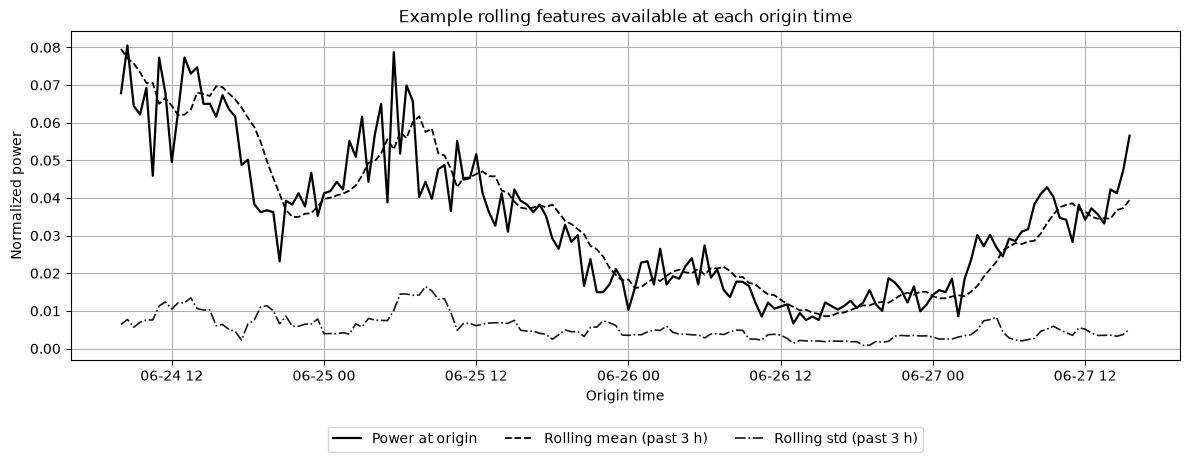

In [3]:
# Create lag and rolling features within each continuous segment
feature_df = df.copy()
grouped_power = feature_df.groupby("continuous_segment_id", dropna=True)[target_col]

for step in lag_steps:
    feature_df[f"power_lag_{step}"] = grouped_power.shift(step)

past_power = grouped_power.shift(1)

for window in roll_mean_windows:
    feature_df[f"power_roll_mean_{window}"] = (
        past_power
        .groupby(feature_df["continuous_segment_id"], dropna=True)
        .rolling(window=window, min_periods=window)
        .mean()
        .reset_index(level=0, drop=True)
    )

for window in roll_std_windows:
    feature_df[f"power_roll_std_{window}"] = (
        past_power
        .groupby(feature_df["continuous_segment_id"], dropna=True)
        .rolling(window=window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
    )


# Build one supervised dataset per horizon
supervised_by_horizon = {}

for horizon_steps, info in horizons.items():
    horizon_df = feature_df.copy()

    horizon_df["target_time"] = (
        horizon_df
        .groupby("continuous_segment_id", dropna=True)[time_col]
        .shift(-horizon_steps)
    )

    horizon_df["y_target_norm"] = (
        horizon_df
        .groupby("continuous_segment_id", dropna=True)[target_col]
        .shift(-horizon_steps)
    )

    horizon_df["horizon_steps"] = horizon_steps
    horizon_df["horizon_hours"] = info["horizon_hours"]
    horizon_df["horizon_label"] = info["horizon_label"]

    supervised_cols = (
        [time_col, "target_time", "continuous_segment_id"]
        + feature_cols
        + ["y_target_norm", target_col, "horizon_steps", "horizon_hours", "horizon_label"]
    )

    horizon_df = horizon_df[supervised_cols].dropna(
        subset=feature_cols + ["y_target_norm"]
    )

    horizon_df = horizon_df.rename(columns={time_col: "origin_time"})

    supervised_by_horizon[horizon_steps] = horizon_df.reset_index(drop=True)


# Supervised sample counts by horizon
supervised_summary = pd.DataFrame(
    [
        {
            "horizon": horizons[horizon_steps]["horizon_label"],
            "horizon_steps": horizon_steps,
            "horizon_hours": horizons[horizon_steps]["horizon_hours"],
            "supervised_rows": len(horizon_df),
            "share_of_available_target_records": len(horizon_df) / df["target_available"].sum() * 100,
        }
        for horizon_steps, horizon_df in supervised_by_horizon.items()
    ]
)

supervised_summary["share_of_available_target_records"] = (
    supervised_summary["share_of_available_target_records"].round(2)
)

display(supervised_summary)


# Example rolling-feature window at origin time
# The same feature construction is used for all forecast horizons,
# so one horizon is enough for illustration.
example_horizon_steps = 2
example_horizon_df = supervised_by_horizon[example_horizon_steps]

example_segment_id = (
    example_horizon_df
    .groupby("continuous_segment_id")
    .size()
    .sort_values(ascending=False)
    .index[0]
)

plot_df = example_horizon_df.loc[
    example_horizon_df["continuous_segment_id"] == example_segment_id
].copy()

window_size = min(len(plot_df), 160)
start_idx = max((len(plot_df) - window_size) // 2, 0)
plot_df = plot_df.iloc[start_idx:start_idx + window_size]

fig, ax = plt.subplots(figsize=(12, 4.8))

ax.plot(
    plot_df["origin_time"],
    plot_df[target_col],
    color="black",
    linewidth=1.6,
    label="Power at origin",
)

ax.plot(
    plot_df["origin_time"],
    plot_df["power_roll_mean_6"],
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Rolling mean (past 3 h)",
)

ax.plot(
    plot_df["origin_time"],
    plot_df["power_roll_std_6"],
    color="black",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.9,
    label="Rolling std (past 3 h)",
)

ax.set_title("Example rolling features available at each origin time")
ax.set_xlabel("Origin time")
ax.set_ylabel("Normalized power")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()

## Rolling-origin folds

The supervised rows are split chronologically into 5 rolling-origin folds.

Each fold uses an expanding chronological prefix of the supervised record. Within each fold, the split is approximately 70% training, 15% calibration/validation, and 15% test. The later folds use longer prefixes, so they include more training and evaluation samples.

The calibration/validation block is kept separate because the same fold structure will later support prediction-interval calibration in the uncertainty analysis.

In [4]:
n_folds = 5

train_fraction = 0.70
calibration_fraction = 0.15
test_fraction = 0.15

folds_dir = Path("../data/processed/folds")
folds_dir.mkdir(parents=True, exist_ok=True)

folds_path = folds_dir / "forecast_folds.parquet"

fold_records = []

for horizon_steps, horizon_df in supervised_by_horizon.items():
    horizon_df = horizon_df.sort_values("origin_time").reset_index(drop=True).copy()
    horizon_df["sample_id"] = np.arange(len(horizon_df))
    supervised_by_horizon[horizon_steps] = horizon_df

    n_rows = len(horizon_df)

    # Use expanding chronological prefixes ending in the later part of the record.
    fold_end_positions = np.linspace(
        int(np.floor(0.80 * n_rows)),
        n_rows,
        n_folds,
        dtype=int,
    )

    if len(np.unique(fold_end_positions)) < n_folds:
        raise ValueError(f"Not enough supervised rows for {n_folds} folds at horizon {horizon_steps}.")

    for fold_id, fold_end in enumerate(fold_end_positions, start=1):
        train_end = int(np.floor(fold_end * train_fraction))
        calibration_end = train_end + int(np.floor(fold_end * calibration_fraction))
        test_end = fold_end

        split_blocks = {
            "train": (0, train_end),
            "calibration": (train_end, calibration_end),
            "test": (calibration_end, test_end),
        }

        for split_name, (start, end) in split_blocks.items():
            split_df = horizon_df.iloc[start:end][
                [
                    "sample_id",
                    "origin_time",
                    "target_time",
                    "horizon_steps",
                    "horizon_hours",
                    "horizon_label",
                ]
            ].copy()

            split_df["fold_id"] = fold_id
            split_df["split"] = split_name

            fold_records.append(split_df)

folds_df = pd.concat(fold_records, ignore_index=True)

folds_df = folds_df[
    [
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "sample_id",
        "origin_time",
        "target_time",
    ]
].sort_values(
    ["horizon_steps", "fold_id", "origin_time"]
).reset_index(drop=True)


# Split counts and percentages within each fold
fold_split_counts = (
    folds_df
    .groupby(["horizon_steps", "horizon_label", "fold_id", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for split_name in ["train", "calibration", "test"]:
    if split_name not in fold_split_counts.columns:
        fold_split_counts[split_name] = 0

fold_split_counts["total"] = (
    fold_split_counts["train"]
    + fold_split_counts["calibration"]
    + fold_split_counts["test"]
)

fold_split_summary = fold_split_counts[
    ["horizon_steps", "horizon_label", "fold_id"]
].copy()

for split_name in ["train", "calibration", "test"]:
    pct = 100 * fold_split_counts[split_name] / fold_split_counts["total"]
    fold_split_summary[split_name] = (
        fold_split_counts[split_name].astype(int).astype(str)
        + " ("
        + pct.round(1).astype(str)
        + "%)"
    )

fold_split_summary = fold_split_summary[
    ["horizon_steps", "horizon_label", "fold_id", "train", "calibration", "test"]
]

fold_split_summary.columns.name = None

display(
    fold_split_summary.sort_values(
        ["horizon_steps", "fold_id"]
    ).reset_index(drop=True)
)


# Save fold structure for downstream uncertainty analysis
folds_df.to_parquet(folds_path, index=False)

print(f"Saved fold definitions to: {folds_path}")

,horizon_steps,horizon_label,fold_id,train,calibration,test
0,1,30 min,1,2724 (70.0%),583 (15.0%),585 (15.0%)
1,1,30 min,2,2894 (70.0%),620 (15.0%),621 (15.0%)
2,1,30 min,3,3065 (70.0%),656 (15.0%),658 (15.0%)
3,1,30 min,4,3235 (70.0%),693 (15.0%),694 (15.0%)
4,1,30 min,5,3406 (70.0%),729 (15.0%),731 (15.0%)
5,2,1 h,1,2698 (70.0%),578 (15.0%),579 (15.0%)
6,2,1 h,2,2867 (70.0%),614 (15.0%),615 (15.0%)
7,2,1 h,3,3035 (70.0%),650 (15.0%),652 (15.0%)
8,2,1 h,4,3204 (70.0%),686 (15.0%),688 (15.0%)
9,2,1 h,5,3373 (70.0%),722 (15.0%),724 (15.0%)


Saved fold definitions to: ../data/processed/folds/forecast_folds.parquet


## Forecasting models

The benchmark uses four simple point-forecasting models:

- **Persistence** — predicts the future value using the current estimated power at the forecast origin. No hyperparameters.
- **Rolling mean** — predicts the future value using a recent rolling mean of estimated power, with the rolling window selected from $w \in \{3, 6, 12\}$ 30-minute steps.
- **Ridge regression** — regularized linear autoregressive model implemented with scikit-learn, with regularization strength selected from $\alpha \in \{0.1, 1.0, 10.0\}$.
- **Random forest regression** — non-linear tree-based benchmark implemented with scikit-learn, with a small grid over tree depth and leaf size: $d_{\max} \in \{6, 12, \mathrm{None}\}$ and $n_{\mathrm{min\ leaf}} \in \{3, 5, 10\}$.

Ridge regression uses a `StandardScaler` inside a scikit-learn pipeline, fitted only on the training block of each fold. The baseline models and random forest do not require feature scaling.

Hyperparameter selection uses a small manual grid search within each fold: models are fitted on the training block, candidate settings are compared on the calibration/validation block, and final performance is reported on the test block.

In [5]:
from sklearn.model_selection import ParameterGrid

model_grids = {
    "Persistence": [{}],
    "RollingMean": [
        {"feature": f"power_roll_mean_{window}"}
        for window in roll_mean_windows
    ],
    "Ridge": [
        {"alpha": alpha}
        for alpha in [0.1, 1.0, 10.0]
    ],
    "RandomForest": list(
        ParameterGrid(
            {
                "max_depth": [6, 12, None],
                "min_samples_leaf": [3, 5, 10],
            }
        )
    ),
}


def build_model(model_name, params):
    if model_name == "Ridge":
        return make_pipeline(
            StandardScaler(),
            Ridge(alpha=params["alpha"]),
        )

    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=random_state,
            n_jobs=-1,
        )

    return None

## Fold-wise model fitting and prediction

For each horizon and fold, candidate model settings are fitted on the training block and compared on the calibration/validation block. The selected setting is then used to generate predictions for the calibration and test blocks.

The test block is not used for model fitting or hyperparameter selection.

The saved prediction table keeps the selected point forecasts and residuals for downstream uncertainty analysis. Fitted fold-specific models are also saved so the selected forecasting objects can be inspected or reused later.

In [ ]:
import json
import time
import joblib
from tqdm import tqdm


models_dir = Path("../outputs/models/notebook_03")
models_dir.mkdir(parents=True, exist_ok=True)

tables_dir = Path("../outputs/tables/notebook_03")
tables_dir.mkdir(parents=True, exist_ok=True)

predictions_path = output_dir / "forecast_predictions.parquet"

model_selection_path = tables_dir / "model_selection.csv"
model_runtime_path = tables_dir / "model_runtime.csv"
selection_summary_path = tables_dir / "model_selection_summary.csv"
runtime_summary_path = tables_dir / "model_runtime_summary.csv"


def format_params(params):
    if not params:
        return ""

    return ", ".join(
        f"{key}={value}"
        for key, value in params.items()
    )


def predict_baseline(model_name, params, data):
    if model_name == "Persistence":
        return data[target_col].to_numpy()

    if model_name == "RollingMean":
        return data[params["feature"]].to_numpy()

    raise ValueError(f"Unknown baseline model: {model_name}")


def fit_model(model_name, params, train_data):
    if model_name in ["Persistence", "RollingMean"]:
        return None

    model = build_model(model_name, params)
    model.fit(train_data[feature_cols], train_data["y_target_norm"])

    return model


def predict_model(model_name, params, model, pred_data):
    if model_name in ["Persistence", "RollingMean"]:
        return predict_baseline(model_name, params, pred_data)

    return model.predict(pred_data[feature_cols])


prediction_records = []
selection_records = []
runtime_records = []

tasks = [
    (horizon_steps, fold_id, model_name)
    for horizon_steps in supervised_by_horizon.keys()
    for fold_id in sorted(folds_df["fold_id"].unique())
    for model_name in model_grids.keys()
]

progress_bar = tqdm(
    tasks,
    desc="Fitting forecast models",
    dynamic_ncols=True,
    leave=True,
)

for horizon_steps, fold_id, model_name in progress_bar:
    progress_bar.set_postfix(
        {
            "horizon": horizons[horizon_steps]["horizon_label"],
            "fold": fold_id,
            "model": model_name,
        }
    )

    horizon_df = supervised_by_horizon[horizon_steps].sort_values("sample_id").reset_index(drop=True)

    fold_rows = folds_df[
        (folds_df["horizon_steps"] == horizon_steps)
        & (folds_df["fold_id"] == fold_id)
    ]

    train_ids = fold_rows.loc[fold_rows["split"] == "train", "sample_id"].to_numpy()
    calibration_ids = fold_rows.loc[fold_rows["split"] == "calibration", "sample_id"].to_numpy()
    test_ids = fold_rows.loc[fold_rows["split"] == "test", "sample_id"].to_numpy()

    train_data = horizon_df.iloc[train_ids].copy()
    calibration_data = horizon_df.iloc[calibration_ids].copy()
    test_data = horizon_df.iloc[test_ids].copy()

    candidate_scores = []
    tuning_start = time.perf_counter()

    for params in model_grids[model_name]:
        fit_start = time.perf_counter()
        candidate_model = fit_model(model_name, params, train_data)
        candidate_fit_time = time.perf_counter() - fit_start

        predict_start = time.perf_counter()
        y_pred_calibration = predict_model(
            model_name,
            params,
            candidate_model,
            calibration_data,
        )
        candidate_predict_time = time.perf_counter() - predict_start

        y_pred_calibration = np.clip(y_pred_calibration, 0, 1)

        calibration_rmse = np.sqrt(
            mean_squared_error(
                calibration_data["y_target_norm"],
                y_pred_calibration,
            )
        )

        calibration_mae = mean_absolute_error(
            calibration_data["y_target_norm"],
            y_pred_calibration,
        )

        candidate_scores.append(
            {
                "params": params,
                "calibration_rmse": calibration_rmse,
                "calibration_mae": calibration_mae,
                "candidate_fit_time_seconds": candidate_fit_time,
                "candidate_predict_time_seconds": candidate_predict_time,
            }
        )

    tuning_time = time.perf_counter() - tuning_start

    best_candidate = sorted(
        candidate_scores,
        key=lambda x: (x["calibration_rmse"], x["calibration_mae"]),
    )[0]

    best_params = best_candidate["params"]
    params_label = format_params(best_params)

    final_fit_start = time.perf_counter()
    final_model = fit_model(model_name, best_params, train_data)
    final_fit_time = time.perf_counter() - final_fit_start

    model_path = models_dir / (
        f"h{horizon_steps:02d}_fold{fold_id:02d}_{model_name.lower()}.pkl"
    )

    model_object = {
        "model_name": model_name,
        "params": best_params,
        "horizon_steps": horizon_steps,
        "horizon_hours": horizons[horizon_steps]["horizon_hours"],
        "horizon_label": horizons[horizon_steps]["horizon_label"],
        "fold_id": fold_id,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "rated_power_kw": rated_power_kw,
        "model": final_model,
    }

    joblib.dump(model_object, model_path, compress=3)

    selection_records.append(
        {
            "horizon_steps": horizon_steps,
            "horizon_label": horizons[horizon_steps]["horizon_label"],
            "fold_id": fold_id,
            "model": model_name,
            "params_label": params_label,
            "model_setting": model_name if not params_label else f"{model_name} ({params_label})",
            "selected_params": json.dumps(best_params),
            "calibration_rmse": best_candidate["calibration_rmse"],
            "calibration_mae": best_candidate["calibration_mae"],
            "tuning_time_seconds": tuning_time,
            "final_fit_time_seconds": final_fit_time,
            "model_path": str(model_path),
        }
    )

    split_predict_times = {}

    for split_name, split_data in [
        ("calibration", calibration_data),
        ("test", test_data),
    ]:
        predict_start = time.perf_counter()

        y_pred = predict_model(
            model_name,
            best_params,
            final_model,
            split_data,
        )

        predict_time = time.perf_counter() - predict_start
        split_predict_times[split_name] = predict_time

        y_pred = np.clip(y_pred, 0, 1)

        pred_df = split_data[
            [
                "sample_id",
                "origin_time",
                "target_time",
                "horizon_steps",
                "horizon_hours",
                "horizon_label",
            ]
        ].copy()

        pred_df["fold_id"] = fold_id
        pred_df["split"] = split_name
        pred_df["model"] = model_name
        pred_df["params_label"] = params_label
        pred_df["model_setting"] = model_name if not params_label else f"{model_name} ({params_label})"
        pred_df["selected_params"] = json.dumps(best_params)

        pred_df["y_true_norm"] = split_data["y_target_norm"].to_numpy()
        pred_df["y_pred_norm"] = y_pred
        pred_df["error_norm"] = pred_df["y_true_norm"] - pred_df["y_pred_norm"]

        pred_df["y_true_kw_250"] = pred_df["y_true_norm"] * rated_power_kw
        pred_df["y_pred_kw_250"] = pred_df["y_pred_norm"] * rated_power_kw
        pred_df["error_kw_250"] = pred_df["error_norm"] * rated_power_kw

        prediction_records.append(pred_df)

    runtime_records.append(
        {
            "horizon_steps": horizon_steps,
            "horizon_label": horizons[horizon_steps]["horizon_label"],
            "fold_id": fold_id,
            "model": model_name,
            "params_label": params_label,
            "model_setting": model_name if not params_label else f"{model_name} ({params_label})",
            "tuning_time_seconds": tuning_time,
            "final_fit_time_seconds": final_fit_time,
            "calibration_predict_time_seconds": split_predict_times["calibration"],
            "test_predict_time_seconds": split_predict_times["test"],
            "model_path": str(model_path),
        }
    )


model_selection_df = pd.DataFrame(selection_records)
model_runtime_df = pd.DataFrame(runtime_records)
forecast_predictions_df = pd.concat(prediction_records, ignore_index=True)


selection_summary = (
    model_selection_df
    .groupby(["horizon_steps", "horizon_label", "model_setting"])
    .agg(
        n_folds=("fold_id", "nunique"),
        mean_calibration_rmse=("calibration_rmse", "mean"),
        mean_calibration_mae=("calibration_mae", "mean"),
    )
    .reset_index()
    .sort_values(["horizon_steps", "mean_calibration_rmse", "mean_calibration_mae"])
)

runtime_summary = (
    model_runtime_df
    .groupby(["horizon_steps", "horizon_label", "model"])
    .agg(
        mean_tuning_time_seconds=("tuning_time_seconds", "mean"),
        mean_final_fit_time_seconds=("final_fit_time_seconds", "mean"),
        mean_test_predict_time_seconds=("test_predict_time_seconds", "mean"),
    )
    .reset_index()
    .sort_values(["horizon_steps", "mean_tuning_time_seconds"])
)


# Save downstream data and human-readable result tables
forecast_predictions_df.to_parquet(predictions_path, index=False)

model_selection_df.to_csv(model_selection_path, index=False)
model_runtime_df.to_csv(model_runtime_path, index=False)
selection_summary.to_csv(selection_summary_path, index=False)
runtime_summary.to_csv(runtime_summary_path, index=False)


display(selection_summary)
display(runtime_summary)

print(f"Saved selected predictions and residuals to: {predictions_path}")
print(f"Saved model-selection table to: {model_selection_path}")
print(f"Saved model-runtime table to: {model_runtime_path}")
print(f"Saved model-selection summary to: {selection_summary_path}")
print(f"Saved model-runtime summary to: {runtime_summary_path}")
print(f"Saved selected fitted models to: {models_dir}")